# Baseline mot tang GMM-HMM va hien tuong chong lan

Notebook nay dua toan bo [x, y, v] vao mot GMM-HMM duy nhat, sau do ve state tren mat phang 2D va khong gian 3D. Muc tieu la quan sat han che cua baseline mot tang va dong co dung pipeline hai tang: tang 1 phan doan duong di, tang 2 phan loai vi mo theo velocity trong tung section.

Ground Truth chi duoc dung trong cell cuoi de doi chieu, khong dung de huan luyen.


Loaded 506 points from dataset\testdataset\tester11_1.txt


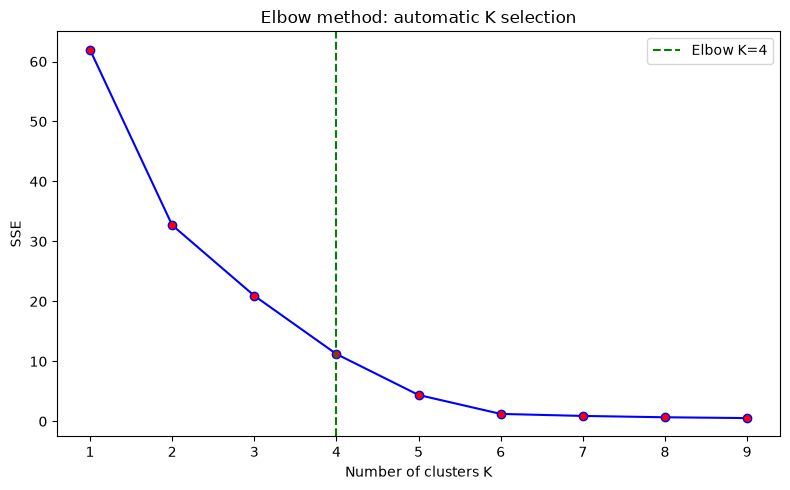

Elbow selected K = 4


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GMMHMM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.cluster import KMeans

DATA_PATH = Path('dataset/testdataset/tester11_1.txt')
N_COMPONENTS = None
RANDOM_STATE = 42
STANDARDIZE = False

matrix = np.atleast_2d(np.loadtxt(DATA_PATH))
if matrix.shape[1] < 3:
    raise ValueError('File phi c t nht ba ct [x, y, v].')
data = matrix[:, :3]
ground_truth = matrix[:, 3].astype(int) if matrix.shape[1] >= 4 else None
X = StandardScaler().fit_transform(data) if STANDARDIZE else data.copy()
print(f'Loaded {len(data)} points from {DATA_PATH}')

# Select K using the Elbow method instead of fixing K=3.
max_k = min(9, len(X))
ks = np.arange(1, max_k + 1)
sse = []
for k in ks:
    km = KMeans(n_clusters=int(k), n_init=10, random_state=RANDOM_STATE)
    km.fit(X)
    sse.append(km.inertia_)
sse = np.asarray(sse)
if len(ks) >= 3:
    x_norm = (ks - ks.min()) / (ks.max() - ks.min())
    y_norm = (sse - sse.min()) / (sse.max() - sse.min() + 1e-12)
    elbow_distance = np.abs(x_norm + y_norm - 1) / np.sqrt(2)
    N_COMPONENTS = int(ks[int(np.argmax(elbow_distance))])
else:
    N_COMPONENTS = int(ks[-1])

plt.figure(figsize=(8, 5))
plt.plot(ks, sse, 'bo-', markerfacecolor='red')
plt.axvline(N_COMPONENTS, color='green', linestyle='--',
            label=f'Elbow K={N_COMPONENTS}')
plt.xlabel('Number of clusters K')
plt.ylabel('SSE')
plt.title('Elbow method: automatic K selection')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Elbow selected K = {N_COMPONENTS}')


## 1. Baseline: mot GMM-HMM tren toan bo [x, y, v]


In [9]:
# K-Means initialization on the complete [x, y, v] feature space.
kmeans_model = KMeans(n_clusters=N_COMPONENTS, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans_model.fit_predict(X)
feature_count = X.shape[1]
means = np.zeros((N_COMPONENTS, 2, feature_count))
covars = np.zeros((N_COMPONENTS, 2, feature_count, feature_count))
for state in range(N_COMPONENTS):
    points = X[kmeans_labels == state]
    if len(points) < 2:
        covariance = np.eye(feature_count) * 1e-3
    else:
        covariance = np.atleast_2d(np.cov(points, rowvar=False))
        if covariance.shape != (feature_count, feature_count):
            covariance = np.eye(feature_count) * 1e-3
    covariance = covariance + np.eye(feature_count) * 1e-3
    means[state, :, :] = kmeans_model.cluster_centers_[state]
    covars[state, :, :, :] = covariance

model = GMMHMM(
    n_components=N_COMPONENTS, n_mix=2, covariance_type='full',
    n_iter=100, tol=1e-5, min_covar=1e-3, random_state=RANDOM_STATE,
    init_params='', params='stmcw'
)
model.startprob_ = np.full(N_COMPONENTS, 0.2 / (N_COMPONENTS - 1))
model.startprob_[0] = 0.8
model.transmat_ = np.full((N_COMPONENTS, N_COMPONENTS), 0.2 / (N_COMPONENTS - 1))
np.fill_diagonal(model.transmat_, 0.8)
model.weights_ = np.full((N_COMPONENTS, 2), 0.5)
model.means_ = means
model.covars_ = covars
model.fit(X)
log_likelihood, states = model.decode(X, algorithm='viterbi')
print(f'Log-likelihood: {log_likelihood:.3f}')
print('K-Means initialized means [x, y, v]:')
print(np.round(kmeans_model.cluster_centers_, 6))
print('Points per state:', np.bincount(states, minlength=N_COMPONENTS))


Log-likelihood: 4481.234
K-Means initialized means [x, y, v]:
[[1.29727e-01 4.93146e-01 6.04000e-04]
 [6.34609e-01 5.38102e-01 6.41000e-04]
 [2.43669e-01 9.21439e-01 1.34300e-03]
 [1.65416e-01 1.57046e-01 3.23000e-04]]
Points per state: [151  68  90 197]


## K-Means khoi tao cho pipeline mot GMM-HMM

K-Means duoc chay truoc voi K duoc chon tu dong bang phuong phap Elbow. Tam cum va covariance cua tung cum duoc dung lam khoi tao cho cac Gaussian state cua GMM-HMM; sau do EM/HMM tiep tuc hoc tham so va Viterbi giai ma chuoi state.


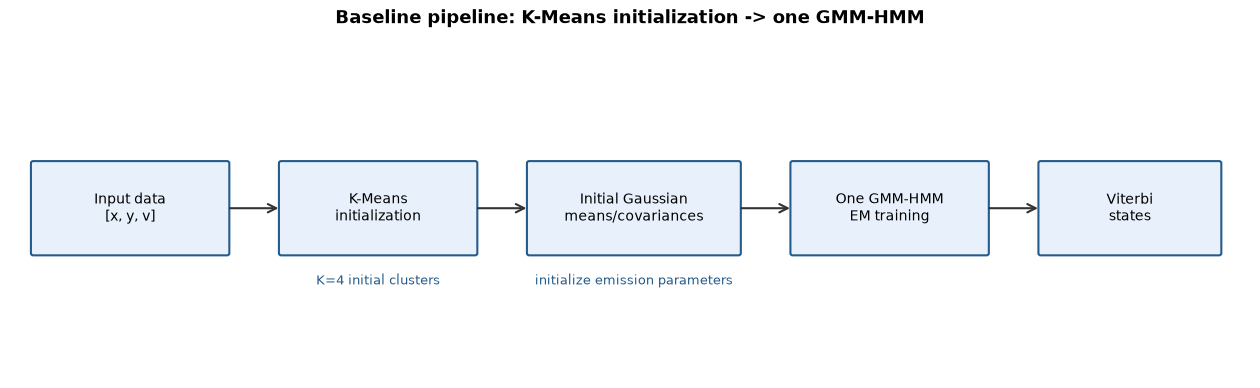

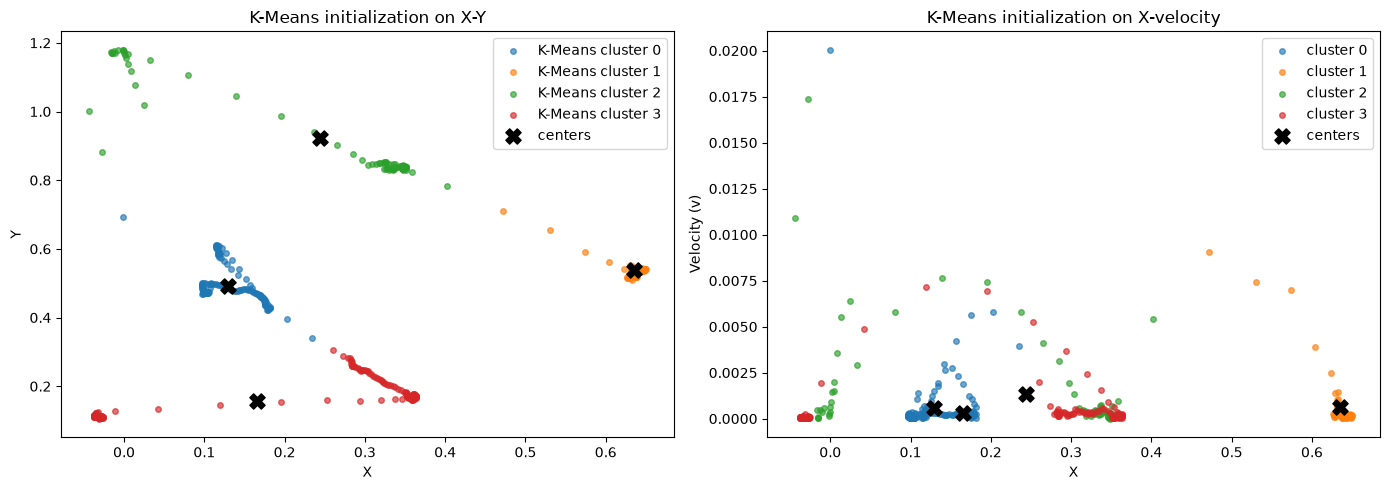

In [10]:
from sklearn.cluster import KMeans
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

kmeans_init = KMeans(n_clusters=N_COMPONENTS, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans_init.fit_predict(X)
kmeans_centers = kmeans_init.cluster_centers_

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 5)
ax.axis('off')
boxes = [
    (0.3, 1.8, 2.5, 1.3, 'Input data\n[x, y, v]'),
    (3.5, 1.8, 2.5, 1.3, 'K-Means\ninitialization'),
    (6.7, 1.8, 2.7, 1.3, 'Initial Gaussian\nmeans/covariances'),
    (10.1, 1.8, 2.5, 1.3, 'One GMM-HMM\nEM training'),
    (13.3, 1.8, 2.3, 1.3, 'Viterbi\nstates'),
]
for x0, y0, width, height, label in boxes:
    ax.add_patch(FancyBboxPatch(
        (x0, y0), width, height, boxstyle='round,pad=0.03',
        facecolor='#E8F1FB', edgecolor='#245B8A', linewidth=1.5
    ))
    ax.text(x0 + width / 2, y0 + height / 2, label,
            ha='center', va='center', fontsize=10)
for start, end in [(2.8, 3.5), (6.0, 6.7), (9.4, 10.1), (12.6, 13.3)]:
    ax.add_patch(FancyArrowPatch(
        (start, 2.45), (end, 2.45), arrowstyle='->',
        mutation_scale=15, linewidth=1.5, color='#333333'
    ))
ax.text(4.75, 1.35, f'K={N_COMPONENTS} initial clusters',
        ha='center', fontsize=9, color='#245B8A')
ax.text(8.05, 1.35, 'initialize emission parameters',
        ha='center', fontsize=9, color='#245B8A')
ax.set_title('Baseline pipeline: K-Means initialization -> one GMM-HMM',
             fontsize=13, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cluster in range(N_COMPONENTS):
    mask = kmeans_labels == cluster
    axes[0].scatter(data[mask, 0], data[mask, 1], s=16,
                    alpha=0.65, label=f'K-Means cluster {cluster}')
axes[0].scatter(kmeans_centers[:, 0], kmeans_centers[:, 1],
                marker='X', s=120, c='black', label='centers')
axes[0].set_title('K-Means initialization on X-Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
for cluster in range(N_COMPONENTS):
    mask = kmeans_labels == cluster
    axes[1].scatter(data[mask, 0], data[mask, 2], s=16,
                    alpha=0.65, label=f'cluster {cluster}')
axes[1].scatter(kmeans_centers[:, 0], kmeans_centers[:, 2],
                marker='X', s=120, c='black', label='centers')
axes[1].set_title('K-Means initialization on X-velocity')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Velocity (v)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 2. Cum baseline tren mat phang 2D [x, y]

Cac mau la state an cua HMM, chua phai Fixation/Pursuit/Saccade. Neu cac mau xen ke hoac phu cung vung [x, y], mot state khong dai dien ro cho mot loai chuyen dong.


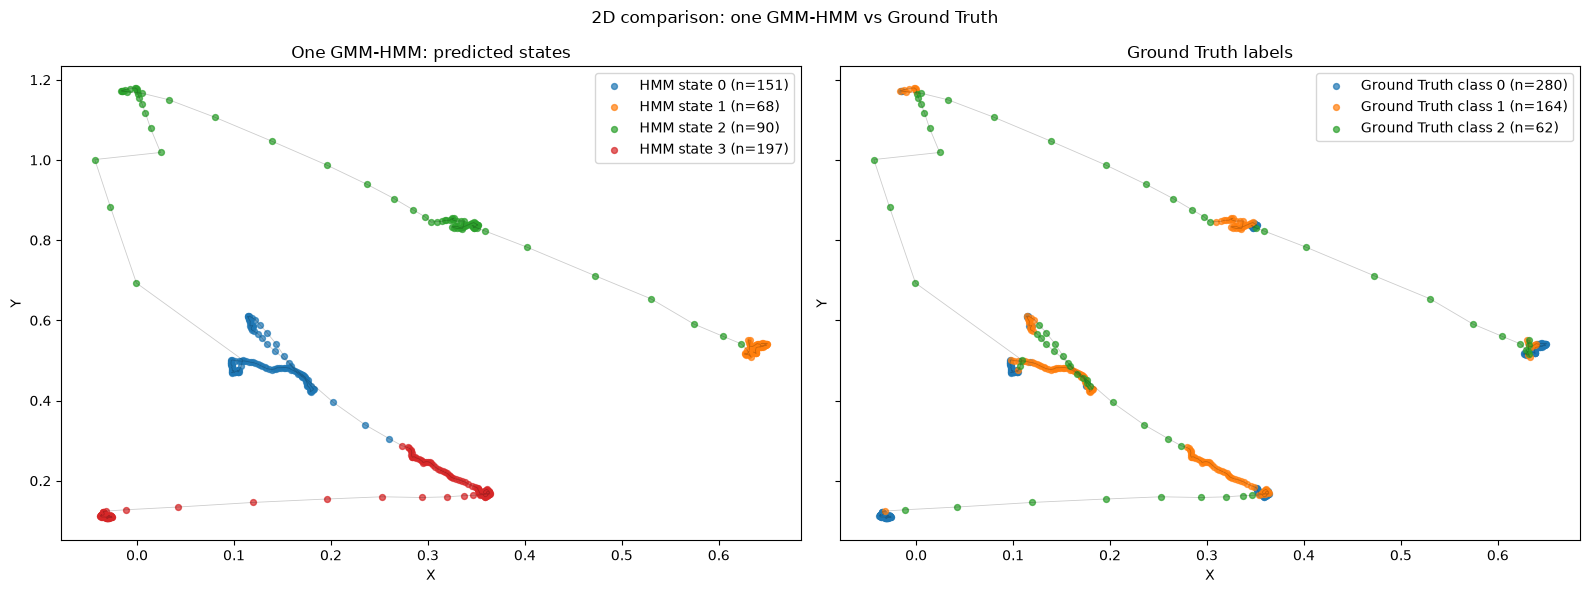

In [11]:
if ground_truth is None:
    fig, ax = plt.subplots(figsize=(10, 6))
    axes = [ax]
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
ax = axes[0]
for state in range(N_COMPONENTS):
    mask = states == state
    ax.scatter(data[mask, 0], data[mask, 1], s=18, alpha=0.7,
               label=f'HMM state {state} (n={mask.sum()})')
ax.plot(data[:, 0], data[:, 1], color='black', alpha=0.2, linewidth=0.6)
ax.set(xlabel='X', ylabel='Y', title='One GMM-HMM: predicted states')
ax.legend()

if ground_truth is not None:
    ax = axes[1]
    for label in np.unique(ground_truth):
        mask = ground_truth == label
        ax.scatter(data[mask, 0], data[mask, 1], s=18, alpha=0.7,
                   label=f'Ground Truth class {label} (n={mask.sum()})')
    ax.plot(data[:, 0], data[:, 1], color='black', alpha=0.2, linewidth=0.6)
    ax.set(xlabel='X', ylabel='Y', title='Ground Truth labels')
    ax.legend()

fig.suptitle('2D comparison: one GMM-HMM vs Ground Truth')
fig.tight_layout()
plt.show()


## 3. Cum baseline trong khong gian 3D [x, y, v]

Truc velocity cho thay cac state co the co mien gia tri giao nhau. Vi vay khong the mac dinh state 0/1/2 lan luot la ba lop vat ly.


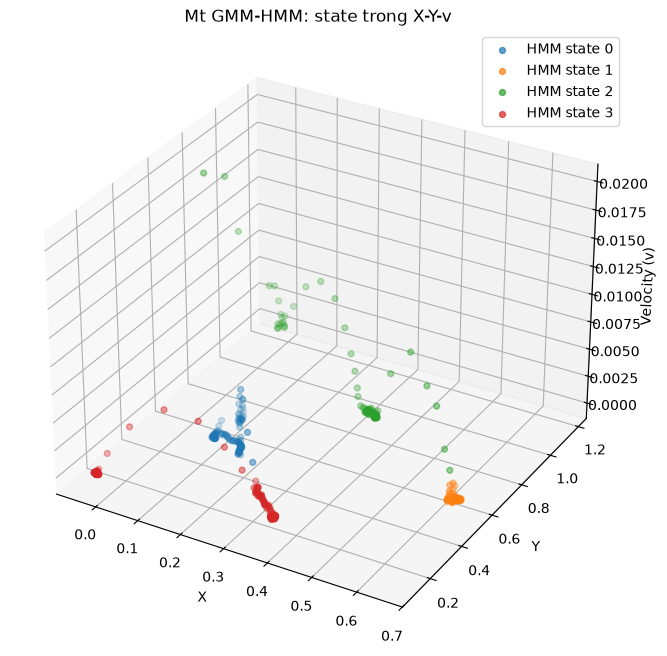

In [12]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
for state in range(N_COMPONENTS):
    mask = states == state
    ax.scatter(data[mask, 0], data[mask, 1], data[mask, 2], s=18,
               alpha=0.7, label=f'HMM state {state}')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Velocity (v)')
ax.set_title('Mt GMM-HMM: state trong X-Y-v')
ax.legend()
plt.show()


## 4. Kiem tra chong lan theo velocity


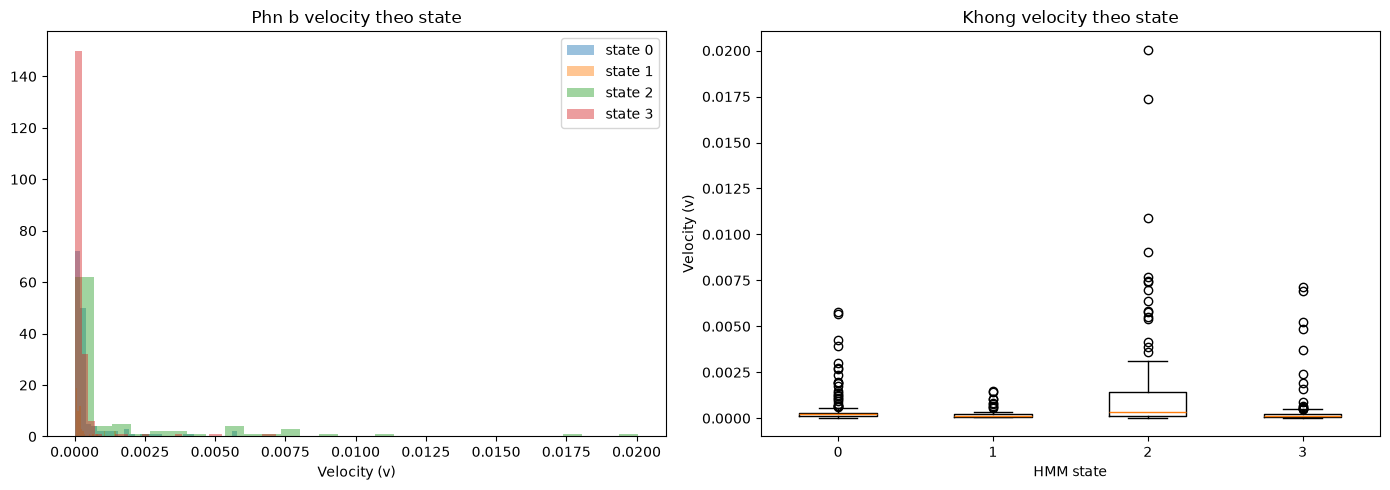

,count,min,median,mean,max
state,,,,,
0,151,0.000009,0.000227,0.000485,0.005795
1,68,0.000043,0.000147,0.000249,0.001461
2,90,0.000008,0.000353,0.001808,0.020046
3,197,0.000009,0.000100,0.000314,0.007160


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for state in range(N_COMPONENTS):
    values = data[states == state, 2]
    axes[0].hist(values, bins=30, alpha=0.45, label=f'state {state}')
    if len(values):
        axes[1].boxplot(values, positions=[state], widths=0.5)
axes[0].set(xlabel='Velocity (v)', title='Phn b velocity theo state')
axes[0].legend()
axes[1].set(xlabel='HMM state', ylabel='Velocity (v)', title='Khong velocity theo state')
plt.tight_layout()
plt.show()
summary = pd.DataFrame(data, columns=['x', 'y', 'v'])
summary['state'] = states
display(summary.groupby('state')['v'].agg(['count', 'min', 'median', 'mean', 'max']))


## 5. Doi chieu Ground Truth (neu file co nhan)

Mot HMM state co the chua nhieu lop Ground Truth. Day la bang chung state an cua baseline khong tu mang ngu nghia Fixation/Pursuit/Saccade.


In [14]:
if ground_truth is None:
    print('File khng c Ground Truth; b qua i chiu.')
else:
    display(pd.crosstab(pd.Series(states, name='HMM state'),
                        pd.Series(ground_truth, name='Ground Truth'),
                        normalize='index').round(3))
    print('Adjusted Rand Index:', round(adjusted_rand_score(ground_truth, states), 4))
    display(pd.DataFrame(confusion_matrix(ground_truth, states)))


Ground Truth,0,1,2
HMM state,,,
0,0.417,0.450,0.132
1,0.794,0.132,0.074
2,0.311,0.389,0.300
3,0.685,0.264,0.051


Adjusted Rand Index: 0.065


,0,1,2,3
0,63,54,28,135
1,68,9,35,52
2,20,5,27,10
3,0,0,0,0


## Ket luan

Baseline mot tang buoc mot model phai hoc dong thoi cau truc duong di [x, y] va phan bo velocity v. Cac state co the chong lan trong [x, y, v], va state ID khong co ngu nghia co dinh. Pipeline hai tang giam van de nay bang cach phan doan chuoi truoc, roi phan loai vi mo theo velocity trong tung section.
